In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib
import warnings

from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# Buat folder jika belum ada
os.makedirs('../output', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# 1. Load Data
print("Memuat dataset...")
df_train = pd.read_csv('../processed/train_2d.csv')
df_test_full = pd.read_csv('../processed/test_full.csv') 
df_test_true = pd.read_csv('../processed/test_2d.csv')

print("Data berhasil dimuat!")

Memuat dataset...
Data berhasil dimuat!


### Persiapan Feature Matrix (X, y) — Base Sensors

In [12]:
# 2. Hanya menggunakan sensor dasar yang sudah dibersihkan (tanpa rolling features)
base_features = [c for c in df_train.columns if c not in ['unit_number', 'time_cycles', 'RUL']]

# Langsung ambil baris terakhir dari Test Full
df_test_last = df_test_full.groupby('unit_number').last().reset_index()

# Siapkan X dan y
X_train = df_train[base_features].values
y_train = df_train['RUL'].values

X_test = df_test_last[base_features].values
y_test = df_test_true['RUL_True'].values 

print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk X_test : {X_test.shape}")

Bentuk X_train: (20631, 17)
Bentuk X_test : (100, 17)


### Training XGBoost

In [13]:
# 3. Menggunakan parameter persis dari notebook referensi
xgb_model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6, 
    n_jobs=-1, 
    random_state=42
)

print('Melatih model XGBoost dengan 100% Data Latih...')

xgb_model.fit(X_train, y_train)
print('Pelatihan selesai!')

Melatih model XGBoost dengan 100% Data Latih...
Pelatihan selesai!


### Evaluasi & Plotting


=== Evaluasi XGBoost (Data Uji) ===
RMSE       : 17.6929
MAE        : 12.8940
R2 Score   : 0.8187
NASA Score : 842.9752


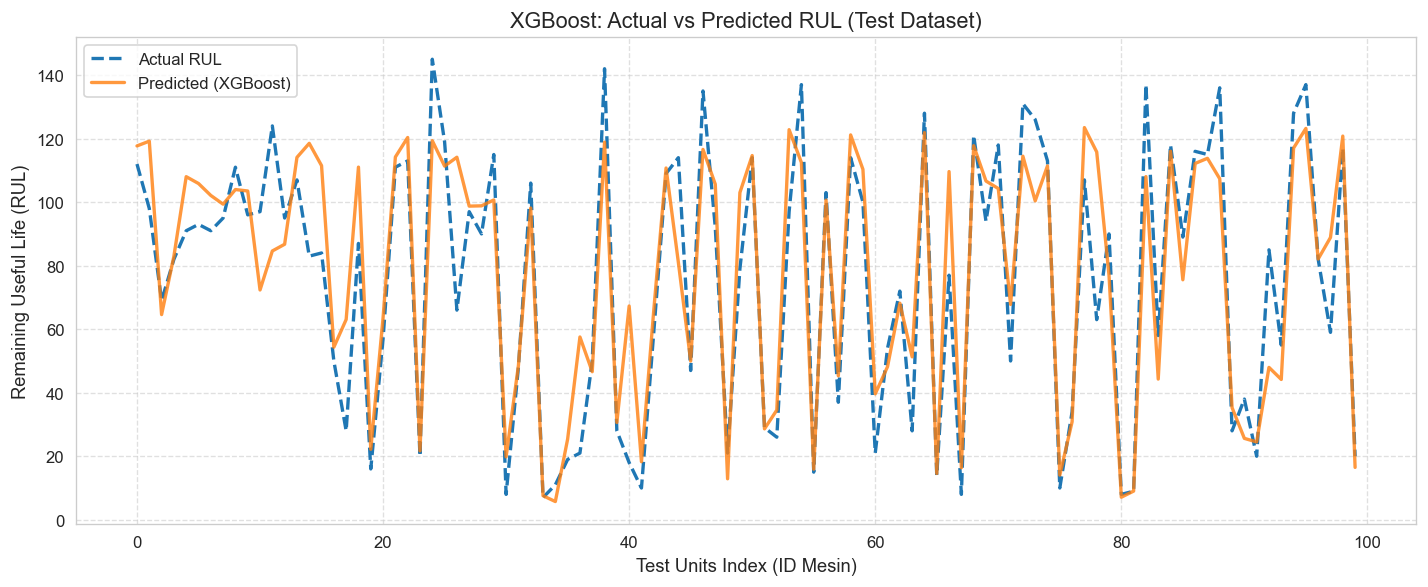

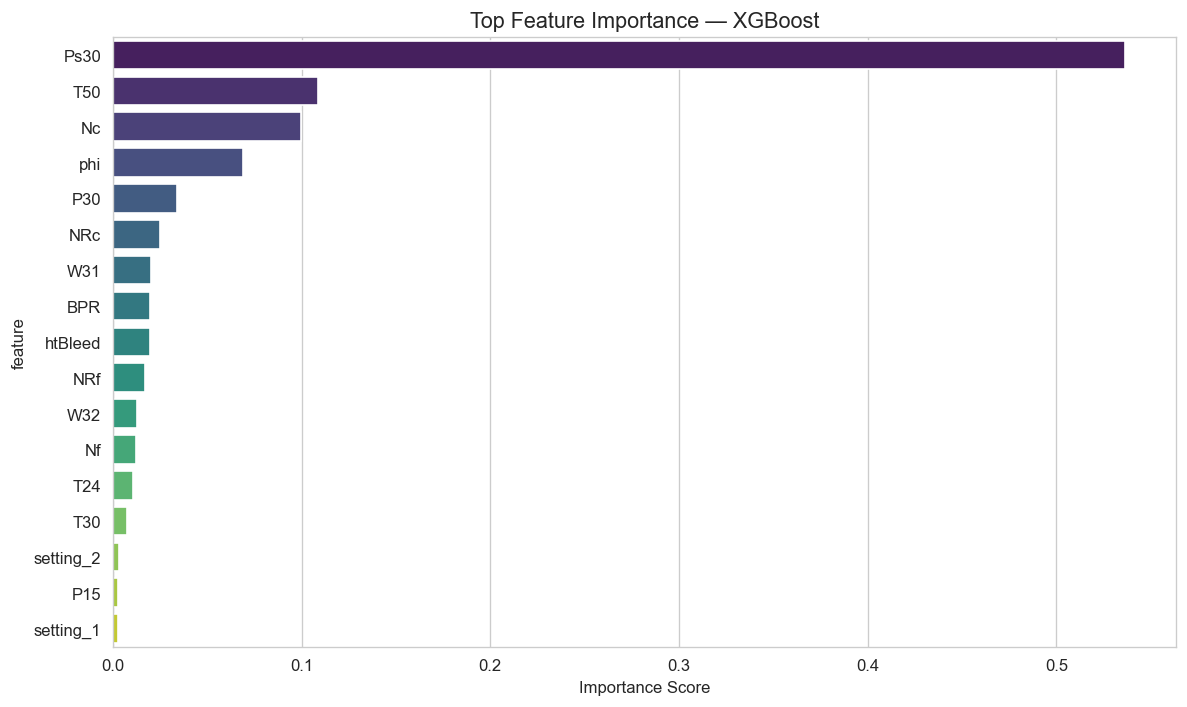

In [14]:
def evaluate_model(y_true, y_pred, model_name='Model'):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    # NASA scoring function
    def nasa_score(y_true, y_pred):
        diff = y_pred - y_true
        score = np.sum(np.where(diff < 0, np.exp(-diff/13) - 1, np.exp(diff/10) - 1))
        return score
    
    ns = nasa_score(y_true, y_pred)
    
    print(f'\n=== Evaluasi {model_name} (Data Uji) ===')
    print(f'RMSE       : {rmse:.4f}')
    print(f'MAE        : {mae:.4f}')
    print(f'R2 Score   : {r2:.4f}')
    print(f'NASA Score : {ns:.4f}')
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'NASA_Score': float(ns)}

# 1. Prediksi Data Test
y_pred_xgb = xgb_model.predict(X_test)
metrics_xgb = evaluate_model(y_test, y_pred_xgb, model_name='XGBoost')

# 2. Plot Prediksi vs Aktual
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual RUL', linestyle='--', color='#1f77b4', linewidth=2)
plt.plot(y_pred_xgb, label='Predicted (XGBoost)', color='#ff7f0e', alpha=0.8, linewidth=2)

plt.title('XGBoost: Actual vs Predicted RUL (Test Dataset)', fontsize=13)
plt.xlabel('Test Units Index (ID Mesin)', fontsize=11)
plt.ylabel('Remaining Useful Life (RUL)', fontsize=11)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../output/xgb_pred_vs_actual_line.png', dpi=300)
plt.show()

# 3. Feature Importance
importance_df = pd.DataFrame({
    'feature': base_features, 
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top Feature Importance — XGBoost', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../output/xgb_feature_importance.png', dpi=300)
plt.show()

### Simpan model

In [15]:
# Simpan model 
joblib.dump(xgb_model, '../models/xgb_model.pkl')

# Simpan hasil prediksi
pred_df = pd.DataFrame({'unit_number': df_test_true['unit_number'], 'y_true': y_test, 'y_pred_xgb': y_pred_xgb})
pred_df.to_csv('../processed/xgb_predictions.csv', index=False)

# Simpan metrik evaluasi
with open('../processed/xgb_metrics.json', 'w') as f:
    json.dump(metrics_xgb, f, indent=2)

print("Model, Prediksi, dan Metrik XGBoost berhasil disimpan!")

Model, Prediksi, dan Metrik XGBoost berhasil disimpan!


### Overfitting Cek

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_train = xgb_model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("=== DETEKSI OVERFITTING ===")
print(f"R2 Score TRAIN : {r2_train:.4f}  (Seberapa baik model menghafal)")
print(f"R2 Score TEST  : {metrics_xgb['R2']:.4f}  (Seberapa baik model di dunia nyata)")
print("-" * 30)

selisih_r2 = r2_train - metrics_xgb['R2']
print(f"Selisih R2     : {selisih_r2:.4f}")

if selisih_r2 > 0.10:
    print("STATUS: Terindikasi OVERFITTING! (Selisih > 10%)")
    print("Saran: Kurangi max_depth, naikkan min_child_weight, atau pakai Early Stopping.")
elif selisih_r2 < 0:
    print("STATUS: Anomali! (Skor Test lebih tinggi dari Train, cek kebocoran data).")
else:
    print("STATUS: AMAN (Good Fit). Model bisa digeneralisasi dengan baik!")

=== DETEKSI OVERFITTING ===
R2 Score TRAIN : 0.8655  (Seberapa baik model menghafal)
R2 Score TEST  : 0.8187  (Seberapa baik model di dunia nyata)
------------------------------
Selisih R2     : 0.0468
STATUS: AMAN (Good Fit). Model bisa digeneralisasi dengan baik!
